# Nome: Raphael de Souza Nunes
# Matrícula: 3250132 

## Import all packages need in the cell below

In [19]:
using Pkg
using Plots
Pkg.add("Plots")
Pkg.add("Optim")
Pkg.add("NLsolve")

gr()

   Resolving package versions...
     Project No packages added to or removed from `C:\Users\rapha\.julia\environments\v1.12\Project.toml`
    Manifest No packages added to or removed from `C:\Users\rapha\.julia\environments\v1.12\Manifest.toml`
   Resolving package versions...
     Project No packages added to or removed from `C:\Users\rapha\.julia\environments\v1.12\Project.toml`
    Manifest No packages added to or removed from `C:\Users\rapha\.julia\environments\v1.12\Manifest.toml`
   Resolving package versions...
     Project No packages added to or removed from `C:\Users\rapha\.julia\environments\v1.12\Project.toml`
    Manifest No packages added to or removed from `C:\Users\rapha\.julia\environments\v1.12\Manifest.toml`


Plots.GRBackend()

## FONC example

Plot the graphics of $f(x) = (x_1 - 3)^2 + (x_2 + 4)^2$

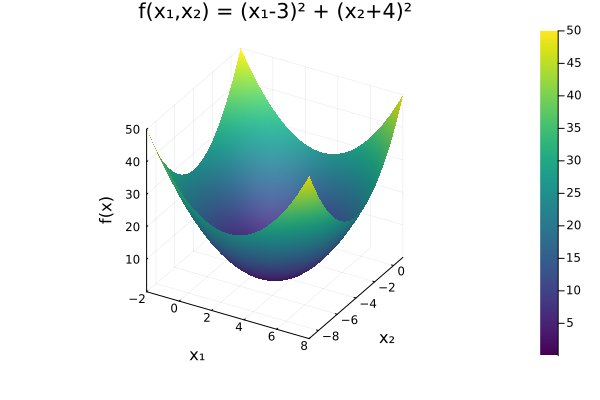

In [20]:
f(x1, x2) = (x1 - 3)^2 + (x2 + 4)^2

x1 = range(-2, 8, length=100)
x2 = range(-9, 1, length=100)
Z = [f(a, b) for b in x2, a in x1]

surface(x1, x2, Z,
    xlabel="x₁", ylabel="x₂", zlabel="f(x)",
    title="f(x₁,x₂) = (x₁-3)² + (x₂+4)²",
    color=:viridis)

## Solving the FONC

Given the function $z = (x_1 - 1)^4 + (x_2 - 2)^4$:

* using the optim.jl package, find the minimum of z.
* using the NLsolve.jl package, solve the FONC problem for this function

In [22]:
using Optim

f(x) = (x[1] - 1)^4 + (x[2] - 2)^4

x0 = [0.0, 0.0]


result = optimize(f, x0, BFGS())

println("=== Optim.jl ===")
println("Mínimo encontrado em: x₁ = ", Optim.minimizer(result)[1], ", x₂ = ", Optim.minimizer(result)[2])
println("Valor mínimo de z: ", Optim.minimum(result))
println(result)

using NLsolve

function fonc!(F, x)
    F[1] = 4 * (x[1] - 1)^3   # ∂z/∂x₁ = 0
    F[2] = 4 * (x[2] - 2)^3   # ∂z/∂x₂ = 0
end

x0 = [0.0, 0.0]

sol = nlsolve(fonc!, x0)

println("=== NLsolve.jl ===")
println("Solução FONC: x₁ = ", sol.zero[1], ", x₂ = ", sol.zero[2])
println("Convergiu: ", converged(sol))

=== Optim.jl ===
Mínimo encontrado em: x₁ = 0.9993307703501523, x₂ = 2.0007158804901986
Valor mínimo de z: 4.632267842351608e-13
 * Status: success

 * Candidate solution
    Final objective value:     4.632268e-13

 * Found with
    Algorithm:     BFGS

 * Convergence measures
    |x - x'|               = 1.01e-03 ≰ 0.0e+00
    |x - x'|/|x'|          = 5.06e-04 ≰ 0.0e+00
    |f(x) - f(x')|         = 1.02e-11 ≰ 0.0e+00
    |f(x) - f(x')|/|f(x')| = 2.19e+01 ≰ 0.0e+00
    |g(x)|                 = 1.47e-09 ≤ 1.0e-08

 * Work counters
    Seconds run:   0  (vs limit Inf)
    Iterations:    13
    f(x) calls:    51
    ∇f(x) calls:   51

=== NLsolve.jl ===
Solução FONC: x₁ = 0.9995401607802424, x₂ = 1.9990803216092672
Convergiu: true


Plot the level curve and the graphics of $f(x) = (x_1 - 3)^2 + (x_2 - 2)^2$

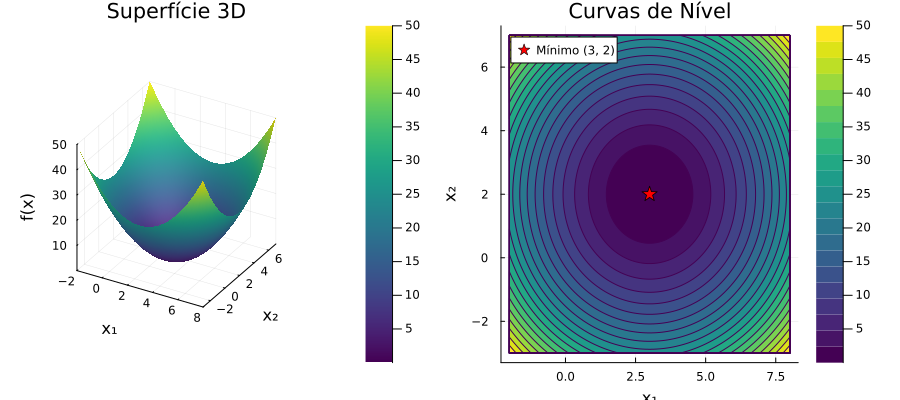

In [23]:
using Plots
gr()


f(x1, x2) = (x1 - 3)^2 + (x2 - 2)^2

x1 = range(-2, 8, length=100)
x2 = range(-3, 7, length=100)
Z = [f(a, b) for b in x2, a in x1]


p1 = surface(x1, x2, Z,
    xlabel="x₁", ylabel="x₂", zlabel="f(x)",
    title="Superfície 3D",
    color=:viridis)

p2 = contourf(x1, x2, Z,
    xlabel="x₁", ylabel="x₂",
    title="Curvas de Nível",
    color=:viridis,
    levels=20)

# Marcar o mínimo em (3, 2)
scatter!(p2, [3], [2],
    label="Mínimo (3, 2)",
    color=:red,
    markersize=8,
    markershape=:star5)

plot(p1, p2, layout=(1,2), size=(900, 400))

Starting from the point $x = [1.0, 1.0]$, implement the gradient descent and Newton method to find the minimum of this function.

In [33]:
# Gradiente descendente

using LinearAlgebra

f(x)    = (x[1] - 3)^2 + (x[2] - 2)^2
delta_f(x)   = [2*(x[1] - 3), 2*(x[2] - 2)]


α       = 0.1        # taxa de aprendizado (step size)
tol     = 1e-6       # tolerância
max_iter = 1000      # máximo de iterações
x       = [1.0, 1.0] # ponto inicial

println("=== Gradient Descent ===")
for i in 1:max_iter
    g = delta_f(x)
    x_new = x - α * g

    if norm(x_new - x) < tol
        println("Convergiu em $i iterações")
        break
    end
    x = x_new
end

println("Mínimo encontrado: x₁ = $(x[1]), x₂ = $(x[2])")
println("Valor de f(x): $(f(x))")

# Método de Newton
using LinearAlgebra

f(x)  = (x[1] - 3)^2 + (x[2] - 2)^2
delta_f(x) = [2*(x[1] - 3), 2*(x[2] - 2)]
H(x)  = [2.0  0.0;      
          0.0  2.0]

# Parâmetros
tol      = 1e-6
max_iter = 100
x        = [1.0, 1.0]   # ponto inicial

println("=== Método de Newton ===")
for i in 1:max_iter
    g     = delta_f(x)
    Hx    = H(x)
    d     = -Hx \ g      # direção
    x_new = x + d

    if norm(x_new - x) < tol
        println("Convergiu em $i iterações")
        break
    end
    x = x_new
end

println("Mínimo encontrado: x₁ = $(x[1]), x₂ = $(x[2])")
println("Valor de f(x): $(f(x))")

=== Gradient Descent ===
Convergiu em 60 iterações
Mínimo encontrado: x₁ = 2.9999961687611476, x₂ = 1.9999980843805738
Valor de f(x): 1.834798893009751e-11
=== Método de Newton ===
Convergiu em 2 iterações
Mínimo encontrado: x₁ = 3.0, x₂ = 2.0
Valor de f(x): 0.0


Implement the same methods now for the function f(x) = 10(x_1 - 3)^2 + 2(x_2 - 2)^2$

In [28]:
using LinearAlgebra

# Gradiente descendente
f(x)  = 10*(x[1] - 3)^2 + 2*(x[2] - 2)^2
delta_f(x) = [20*(x[1] - 3), 4*(x[2] - 2)]
H(x)  = [20.0  0.0;
          0.0   4.0]

α        = 0.01  
tol      = 1e-6
max_iter = 10000
x        = [1.0, 1.0]

println("=== Gradiente Descendente ===")
history_gd = [copy(x)]

for i in 1:max_iter
    g     = delta_f(x)
    x_new = x - α * g

    push!(history_gd, copy(x_new))

    if norm(x_new - x) < tol
        println("Convergiu em $i iterações")
        break
    end
    x = x_new
end

println("Mínimo encontrado: x₁ = $(x[1]), x₂ = $(x[2])")
println("Valor de f(x): $(f(x))")


# Metodo de newton

# Parâmetros
tol      = 1e-6
max_iter = 100
x        = [1.0, 1.0]

println("=== Método de Newton ===")
history_nm = [copy(x)]

for i in 1:max_iter
    g     = delta_f(x)
    Hx    = H(x)
    d     = -Hx \ g       # direção de Newton: d = -H⁻¹ delta_f
    x_new = x + d

    push!(history_nm, copy(x_new))

    if norm(x_new - x) < tol
        println("Convergiu em $i iterações")
        break
    end
    x = x_new
end

println("Mínimo encontrado: x₁ = $(x[1]), x₂ = $(x[2])")
println("Valor de f(x): $(f(x))")

=== Gradiente Descendente ===
Convergiu em 261 iterações
Mínimo encontrado: x₁ = 2.999999999999999, x₂ = 1.9999754234685199
Valor de f(x): 1.208011799188237e-9
=== Metodo de Newton ===
Convergiu em 2 iterações
Mínimo encontrado: x₁ = 3.0, x₂ = 2.0
Valor de f(x): 0.0


Now implement the same methods for the function $f(x) = x_1^2 + x_2^2$. Use as start point $x_0 = [-2.0, 2.0]$

In [29]:
using LinearAlgebra

# Função, gradiente e Hessiana
f(x)  = x[1]^2 + x[2]^2
delta_f(x) = [2*x[1], 2*x[2]]
H(x)  = [2.0  0.0;
          0.0  2.0]

# Parâmetros
α        = 0.1
tol      = 1e-6
max_iter = 10000
x        = [-2.0, 2.0]   # ponto inicial

println("=== Gradiente Descendente ===")
history_gd = [copy(x)]

for i in 1:max_iter
    g     = delta_f(x)
    x_new = x - α * g

    push!(history_gd, copy(x_new))

    if norm(x_new - x) < tol
        println("Convergiu em $i iterações")
        break
    end
    x = x_new
end

println("Mínimo encontrado: x₁ = $(x[1]), x₂ = $(x[2])")
println("Valor de f(x): $(f(x))")


# Parâmetros
tol      = 1e-6
max_iter = 100
x        = [-2.0, 2.0]   # ponto inicial

println("=== Método de Newton ===")
history_nm = [copy(x)]

for i in 1:max_iter
    g     = delta_f(x)
    Hx    = H(x)
    d     = -Hx \ g
    x_new = x + d

    push!(history_nm, copy(x_new))

    if norm(x_new - x) < tol
        println("Convergiu em $i iterações")
        break
    end
    x = x_new
end

println("Mínimo encontrado: x₁ = $(x[1]), x₂ = $(x[2])")
println("Valor de f(x): $(f(x))")

=== Gradiente Descendente ===
Convergiu em 61 iterações
Mínimo encontrado: x₁ = -3.0649910817317793e-6, x₂ = 3.0649910817317793e-6
Valor de f(x): 1.8788340662190685e-11
=== Método de Newton ===
Convergiu em 2 iterações
Mínimo encontrado: x₁ = 0.0, x₂ = 0.0
Valor de f(x): 0.0


Implement the same methods for the function $f(x) = x_1^2 + 100x_2^2$. Use as start point $x_0 = [-2.0, 2.0]$

In [30]:
using LinearAlgebra

# Função, gradiente e Hessiana
f(x)  = x[1]^2 + 100*x[2]^2
delta_f(x) = [2*x[1], 200*x[2]]
H(x)  = [2.0    0.0;
          0.0  200.0]

# Parâmetros
α        = 0.009  
tol      = 1e-6
max_iter = 100000
x        = [-2.0, 2.0]

println("=== Gradient Descent ===")
history_gd = [copy(x)]

for i in 1:max_iter
    g     = delta_f(x)
    x_new = x - α * g

    push!(history_gd, copy(x_new))

    if norm(x_new - x) < tol
        println("Convergiu em $i iterações")
        break
    end
    x = x_new
end

println("Mínimo encontrado: x₁ = $(x[1]), x₂ = $(x[2])")
println("Valor de f(x): $(f(x))")

# Parâmetros
tol      = 1e-6
max_iter = 100
x        = [-2.0, 2.0]

println("=== Método de Newton ===")
history_nm = [copy(x)]

for i in 1:max_iter
    g     = delta_f(x)
    Hx    = H(x)
    d     = -Hx \ g
    x_new = x + d

    push!(history_nm, copy(x_new))

    if norm(x_new - x) < tol
        println("Convergiu em $i iterações")
        break
    end
    x = x_new
end

println("Mínimo encontrado: x₁ = $(x[1]), x₂ = $(x[2])")
println("Valor de f(x): $(f(x))")

=== Gradient Descent ===
Convergiu em 579 iterações
Mínimo encontrado: x₁ = -5.5140403082297186e-5, x₂ = 1.93661136868462e-56
Valor de f(x): 3.040464052078209e-9
=== Newton's Method ===
Convergiu em 2 iterações
Mínimo encontrado: x₁ = 0.0, x₂ = 0.0
Valor de f(x): 0.0


For the last problem, perform the change of variables: $x_2 = \frac{1}{10}y_2$

In [34]:
using LinearAlgebra

g(y)  = y[1]^2 + y[2]^2
delta_g(y) = [2*y[1], 2*y[2]]
Hg(y) = [2.0  0.0;
          0.0  2.0]

α        = 0.1
tol      = 1e-6
max_iter = 10000
y        = [-2.0, 20.0]   # y₂ = 10 * x₂

println("=== Gradiente Descendente ===")
history_gd_y = [copy(y)]

for i in 1:max_iter
    g_grad = delta_g(y)
    y_new  = y - α * g_grad

    push!(history_gd_y, copy(y_new))

    if norm(y_new - y) < tol
        println("Convergiu em $i iterações")
        break
    end
    y = y_new
end

# Conversão de volta para x
x1_sol = y[1]
x2_sol = y[2] / 10

println("Solução em y: y₁ = $(y[1]), y₂ = $(y[2])")
println("Solução em x: x₁ = $(x1_sol), x₂ = $(x2_sol)")
println("Valor de f(x): $(x1_sol^2 + 100*x2_sol^2)")

tol      = 1e-6
max_iter = 100
y        = [-2.0, 20.0]

println("=== Método de Newton ===")
history_nm_y = [copy(y)]

for i in 1:max_iter
    g_grad = delta_g(y)
    Hy     = Hg(y)
    d      = -Hy \ g_grad
    y_new  = y + d

    push!(history_nm_y, copy(y_new))

    if norm(y_new - y) < tol
        println("Convergiu em $i iterações")
        break
    end
    y = y_new
end

x1_sol = y[1]
x2_sol = y[2] / 10

println("Solução em y: y₁ = $(y[1]), y₂ = $(y[2])")
println("Solução em x: x₁ = $(x1_sol), x₂ = $(x2_sol)")
println("Valor de f(x): $(x1_sol^2 + 100*x2_sol^2)")

=== Gradiente Descendente ===
Convergiu em 70 iterações
Solução em y: y₁ = -4.113761393303017e-7, y₂ = 4.113761393303017e-6
Solução em x: x₁ = -4.113761393303017e-7, x₂ = 4.113761393303017e-7
Valor de f(x): 1.7092263129040683e-11
=== Método de Newton ===
Convergiu em 2 iterações
Solução em y: y₁ = 0.0, y₂ = 0.0
Solução em x: x₁ = 0.0, x₂ = 0.0
Valor de f(x): 0.0


##  Gradient Descent with Backtracking Line Search:

Given function:
\begin{align*}
    f(x_1, x_2, x_3) = x_{3} \log \Big( e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}} \Big) + (x_{3}-2)^2 + e^{\frac{1}{x_{1} + x_{2}}}
\end{align*}

$ \textbf{dom} \; f: \{ \mathbf{x} \in \mathbb{R}^3 : x_1 +x _2 >0, x_3 > 0 \}  $

Define the function in the cell below:

In [ ]:
f(x) = x[3] * log(exp(x[1]/x[3]) + exp(x[2]/x[3])) + (x[3] - 2)^2 + exp(1/(x[1] + x[2]))

Defining the first derivative: 

$\nabla f = [ \partial f/\partial x_1 \; \partial f/\partial x_2 \; \partial f/\partial x_3]^T   $

$$ \implies \nabla f = \begin{Bmatrix}
\frac{e^{\frac{x_{1}} {x_{3}}}}{e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}} - \frac{e^{ \frac{1}{x_1 + x_2}}}{(x_1 +x_2)^2}  \\ \\
\frac{e^{\frac{x_{2}} {x_{3}}}}{e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}} - \frac{e^{ \frac{1}{x_1 + x_2}}}{(x_1 +x_2)^2} \\ \\
 log(e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}) - \frac{x_1 e^{\frac{x_{1}} {x_{3}}} + x_2 e^{\frac{x_{2}} {x_{3}}}}{x_3 ( e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}) } + 2(x_3-2)
\end{Bmatrix}$$

#### implement the first derivative 

In [ ]:
function grad_f(x)
    e1 = exp(x[1]/x[3])
    e2 = exp(x[2]/x[3])
    S  = e1 + e2
    e12 = exp(1/(x[1] + x[2]))

    df1 = e1/S - e12/(x[1] + x[2])^2
    df2 = e2/S - e12/(x[1] + x[2])^2
    df3 = log(S) - (x[1]*e1 + x[2]*e2)/(x[3]*S) + 2*(x[3] - 2)

    return [df1, df2, df3]
end

Defining parameters for backtracking search: $\alpha = 0,4; \beta = 0,5;$ tolerance (eps) $= 10^{-5}$

In [ ]:
alpha = 0.4
beta = 0.5
eps = 1e-5

Start Point: [3.0, 4.0, 5.0]

In [ ]:
x0 = [3.0, 4.0, 5.0]

Ensuring domain:

$ \text{While} \; x + t\Delta x \notin \textbf{dom} f, \text{ set } t := \beta t $ \
where, $\Delta x = -\nabla f(x)$

In [ ]:
function ensure_domain(x, dx, t, beta)
    while (x[1] + t*dx[1]) + (x[2] + t*dx[2]) <= 0 || (x[3] + t*dx[3]) <= 0
        t *= beta
    end
    return t
end

Backtracking algorithm:

$
\text{Given a descent direction } \Delta x = -\nabla f(x) \text{ for } f \text{ at } x \in \textbf{dom} f, \alpha \in (0, 0.5), \beta \in (0, 1).$

\begin{array}{l}
\text{Set } t := 1. \\ 
\text{Ensure domain:} \; \text{While} \; x + t\Delta x \notin \textbf{dom} f, \text{ set } t := \beta t \\
\text{While } f(x + t\Delta x) > f(x) + \alpha t \nabla f(x)^T \Delta x, \text{ set } t := \beta t.
\end{array}


In [ ]:
function backtracking(f, x, dx, grad, alpha, beta)
    t = 1.0
    t = ensure_domain(x, dx, t, beta)
    while f(x + t*dx) > f(x) + alpha*t*(grad'*dx)
        t *= beta
    end
    return t
end

### Algorithm: Gradient Descent

1. **Input:** Starting point $x$ in $\text{dom} \, f$

2. **Repeat until stopping criterion is satisfied:**

    a. $\Delta x := -\nabla f(x)$
    
    b. **Line search:** Choose step size $t$ via backtracking line search
    
    c. **Update:** $x := x + t \Delta x$

In [1]:
function gradient_descent(f, grad_f, x0, alpha, beta, eps)
    x = copy(x0)
    while norm(grad_f(x)) > eps
        dx = -grad_f(x)
        t = backtracking(f, x, dx, grad_f(x), alpha, beta)
        x = x + t*dx
    end
    return x
end

## Optimisation using Newton's Method:

Given function:
\begin{align*}
    f(x_1, x_2, x_3) = x_{3} \log \Big( e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}} \Big) + (x_{3}-2)^2 + e^{\frac{1}{x_{1} + x_{2}}}
\end{align*}

$ \textbf{dom} \; f: \{ \mathbf{x} \in \mathbb{R}^3 : x_1 +x _2 >0, x_3 > 0 \}  $

Defining the first derivative: 

$\nabla f = [ \partial f/\partial x_1 \; \partial f/\partial x_2 \; \partial f/\partial x_3]^T   $

$$ \implies \nabla f = \begin{Bmatrix}
\frac{e^{\frac{x_{1}} {x_{3}}}}{e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}} - \frac{e^{ \frac{1}{x_1 + x_2}}}{(x_1 +x_2)^2}  \\ \\
\frac{e^{\frac{x_{2}} {x_{3}}}}{e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}} - \frac{e^{ \frac{1}{x_1 + x_2}}}{(x_1 +x_2)^2} \\ \\
 log(e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}) - \frac{x_1 e^{\frac{x_{1}} {x_{3}}} + x_2 e^{\frac{x_{2}} {x_{3}}}}{x_3 ( e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}) } + 2(x_3-2)
\end{Bmatrix}$$

Defining the Second Derivative:

The gradient vector, denoted as $\nabla f$, is the vector of partial derivatives:
$
\nabla f(x) = \left(\frac{\partial f}{\partial x_1}, \frac{\partial f}{\partial x_2}, \ldots, \frac{\partial f}{\partial x_n}\right)
$

The finite difference approximation for the gradient at a point $x$ is given by:
$
\nabla_f(x) \approx \frac{f(x + h\mathbf{i}) - f(x)}{h}
$
where $\mathbf{i}$ is a unit vector along one of the coordinate axes.

The second derivative matrix is then approximated as:
$
\nabla^2 f(x) \approx \frac{1}{h} \left(\nabla_f(x + h\mathbf{i}) - \nabla_f(x)\right)
$

The reshaped second derivative matrix is a $3 \times 3$ matrix obtained from the flattened vector.

In [ ]:
function hessian_f(x, h=1e-5)
    n = length(x)
    H = zeros(n, n)
    g0 = grad_f(x)
    for i in 1:n
        x_new = copy(x)
        x_new[i] += h
        H[:, i] = (grad_f(x_new) - g0) / h
    end
    return H
end

Defining parameters for backtracking search and the start point: $\alpha = 0,4; \beta = 0,5;$ tolerance (eps) $= 10^{-5}$; Start Point: [3.0, 4.0, 5.0]

In [ ]:
alpha = 0.4
beta = 0.5
eps = 1e-5
x0 = [3.0, 4.0, 5.0]

Ensuring domain:

$ \text{While} \; x + t\Delta x \notin \textbf{dom} f, \text{ set } t := \beta t $ \
where
$\Delta x = -\nabla^2 f(x)^{-1} \nabla f(x)$

In [ ]:
function ensure_domain_newton(x, dx, t, β)
    while (x[1] + t*dx[1]) + (x[2] + t*dx[2]) <= 0 || (x[3] + t*dx[3]) <= 0
        t *= β
    end
    return t
end

Backtracking algorithm:

$
\text{Given a descent direction } \Delta x = -\nabla^2 f(x)^{-1} \nabla f(x) \text{ for } f \text{ at } x \in \textbf{dom} f, \alpha \in (0, 0.5), \beta \in (0, 1).$

\begin{array}{l}
\text{Set } t := 1. \\ 
\text{Ensure domain:} \; \text{While} \; x + t\Delta x \notin \textbf{dom} f, \text{ set } t := \beta t \\
\text{While } f(x + t\Delta x) > f(x) + \alpha t \nabla f(x)^T \Delta x, \text{ set } t := \beta t.
\end{array}


In [ ]:
function backtracking_newton(f, x, dx, grad, alpha, beta)
    t = 1.0
    t = ensure_domain_newton(x, dx, t, beta)
    while f(x + t*dx) > f(x) + alpha*t*(grad'*dx)
        t *= beta
    end
    return t
end


# code

### Newton's Algorithm

**Input:** (defined earlier)
- Starting point $x \in \text{dom} \, f$
- Tolerance $\varepsilon > 0$

**Repeat:**
1. Compute the Newton step and decrement.
   $
   \Delta x_{nt} := -\nabla^2 f(x)^{-1}\nabla f(x); \quad \lambda^2 := \nabla f(x)^T \nabla^2 f(x)^{-1}\nabla f(x)
   $
2. Stopping criterion. $\textbf{quit}$ if $\lambda^2/2 \leq \varepsilon.$
3. Line search. Choose step size $t$ by backtracking line search; ensuring update $ := x + t \Delta x$ lies in $\mathbf{dom} f$ throughout.
4. Update. $x := x + t\Delta x_{nt}$.

In [ ]:
function newton_method(f, grad_f, hessian_f, x0, alpha, beta, eps)
    x = copy(x0)
    while true
        g = grad_f(x)
        H = hessian_f(x)
        dx = -H \ g
        lambda2 = g' * (H \ g)
        if lambda2/2 <= eps
            break
        end
        t = backtracking_newton(f, x, dx, g, alpha, beta)
        x = x + t*dx
    end
    return x
end

## Optimisation using Quasi-Newton Method:
### The Broyden-Fletcher-Goldfarb-Shanno (BFGS) update
  

Given function:
\begin{align*}
    f(x_1, x_2, x_3) = x_{3} \log \Big( e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}} \Big) + (x_{3}-2)^2 + e^{\frac{1}{x_{1} + x_{2}}}
\end{align*}

$ \textbf{dom} \; f: \{ \mathbf{x} \in \mathbb{R}^3 : x_1 +x _2 >0, x_3 > 0 \}  $

Defining the first derivative: 

$\nabla f = [ \partial f/\partial x_1 \; \partial f/\partial x_2 \; \partial f/\partial x_3]^T   $

$$ \implies \nabla f = \begin{Bmatrix}
\frac{e^{\frac{x_{1}} {x_{3}}}}{e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}} - \frac{e^{ \frac{1}{x_1 + x_2}}}{(x_1 +x_2)^2}  \\ \\
\frac{e^{\frac{x_{2}} {x_{3}}}}{e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}} - \frac{e^{ \frac{1}{x_1 + x_2}}}{(x_1 +x_2)^2} \\ \\
 log(e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}) - \frac{x_1 e^{\frac{x_{1}} {x_{3}}} + x_2 e^{\frac{x_{2}} {x_{3}}}}{x_3 ( e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}) } + 2(x_3-2)
\end{Bmatrix}$$

Defining the Second Derivative:

The gradient vector, denoted as $\nabla f$, is the vector of partial derivatives:
$
\nabla f(x) = \left(\frac{\partial f}{\partial x_1}, \frac{\partial f}{\partial x_2}, \ldots, \frac{\partial f}{\partial x_n}\right)
$

The finite difference approximation for the gradient at a point $x$ is given by:
$
\nabla_f(x) \approx \frac{f(x + h\mathbf{i}) - f(x)}{h}
$
where $\mathbf{i}$ is a unit vector along one of the coordinate axes.

The second derivative matrix is then approximated as:
$
\nabla^2 f(x) \approx \frac{1}{h} \left(\nabla_f(x + h\mathbf{i}) - \nabla_f(x)\right)
$

The reshaped second derivative matrix is a $3 \times 3$ matrix obtained from the flattened vector.

In [ ]:
function hessian_f(x, h=1e-5)
    n = length(x)
    H = zeros(n, n)
    g0 = grad_f(x)
    for i in 1:n
        x_new = copy(x)
        x_new[i] += h
        H[:, i] = (grad_f(x_new) - g0) / h
    end
    return H
end

Defining parameters for backtracking search and the start point: $\alpha = 0,4; \beta = 0,5;$ tolerance (eps) $= 10^{-5}$; Start Point: [3.0, 4.0, 5.0]

In [ ]:
alpha = 0.4
beta = 0.5
eps = 1e-5
x0 = [3.0, 4.0, 5.0]

Ensuring domain:

$ \text{While} \; x + t\Delta x \notin \textbf{dom} f, \text{ set } t := \beta t $ 

Here, the direction $\Delta x$ has been taken as a parameter in the defined function and thus we need not explicitly calculate it again.

In [ ]:
function ensure_domain(x, dx, t, beta)
    while (x[1] + t*dx[1]) + (x[2] + t*dx[2]) <= 0 || (x[3] + t*dx[3]) <= 0
        t *= beta
    end
    return t
end

Backtracking algorithm:

$
\text{Given a descent direction } \Delta x  \text{ for } f \text{ at } x \in \textbf{dom} f, \alpha \in (0, 0.5), \beta \in (0, 1).$

\begin{array}{l}
\text{Set } t := 1. \\ 
\text{Ensure domain:} \; \text{While} \; x + t\Delta x \notin \textbf{dom} f, \text{ set } t := \beta t \\
\text{While } f(x + t\Delta x) > f(x) + \alpha t \nabla f(x)^T \Delta x, \text{ set } t := \beta t.
\end{array}


In [ ]:
function backtracking(f, x, dx, grad, alpha, beta)
    t = 1.0
    t = ensure_domain(x, dx, t, beta)
    while f(x + t*dx) > f(x) + alpha*t*(grad'*dx)
        t *= beta
    end
    return t
end

### Running the BFGS Algorithm: 

**Given:**
- Starting point $x_0$
- Convergence tolerance $\epsilon > 0$ $(=10^{-5})$
- Starting matrix $H_0$ (taken as Identity matrix)
  
**Initialization:** $k \gets 0$

**While:** $\| \nabla f_k \| > \epsilon$
1. Compute search direction by solving:
   $ p_k = - H_k \nabla f_k $
2. Set $x_{k+1} = x_k + \alpha_k p_k$, where $\alpha_k$ is computed from backtracking line search procedure.
3. Define $s_k = x_{k+1} - x_k$ and $y_k = \nabla f_{k+1} - \nabla f_k$.
4. Compute $H_{k+1}$ using BFGS.
5. $k \gets k + 1$

Finally, as mentioned in the implementation note to set $\rho_k $ as a constant after $y^T_k s_k$ gets smaller some certain $\epsilon$ say $10^{-5}$.\
We have used an $\epsilon = 10^{-4}$ and set the value for  $\rho_k = 10^{4}$.


In [ ]:
function bfgs(f, grad_f, x0, alpha, beta, eps)
    x = copy(x0)
    n = length(x)
    H = Matrix{Float64}(I, n, n)
    k = 0

    while norm(grad_f(x)) > eps
        g = grad_f(x)
        p = -H * g
        t = backtracking(f, x, p, g, alpha, beta)
        x_new = x + t * p
        s = x_new - x
        y = grad_f(x_new) - g
        x = x_new
        rho = y' * s < 1e-4 ? 1e4 : 1.0 / (y' * s)
        H = (I - rho * s * y') * H * (I - rho * y * s') + rho * s * s'
        k += 1
    end

    println("Number of iterations: ", k)
    println("Optimal point: ", x)
    println("Optimal value: ", f(x))
    return x
end

x_bfgs = bfgs(f, grad_f, x0, alpha, beta, eps)

# Problem Statement: Optimal Control for CSTR

We are given the liearized discrete state space model, time horizon, initial state, setpoints for controlled variables, and variable bounds 

In [ ]:
# IMPORTS

#### Defining state space model, time horizon, initial state, and variable bounds

Note: since it is assumed that all the states are measurable without noise, here the controlled variables are represented using x instead for simplicity

Hints: use matrix A, B from material. Time horizon = 3; Initial condition: [-0.03, 0.0, 0.3]; bounds: xmax = [0.05, 5, 0.5]; xmin = [-0.05, -5, -0.5]; umax = [10, 0.05]; umin = [-10, -0.05]

In [ ]:
# linear state-space model

# code

# time horizon
# code

# initial condition
# code

# bounds for state and input
# code


## Model

The LP model for the problem can be derived as follows:


\begin{aligned}
\min_{u(0),u(1),u(2)} \quad &\sum_{k=0}^{k=3} (z_1(k)+z_2(k)) \\
\textit{s.t.} \quad &{x}(k+1) ={A} {x}(k)+{B u}(k) \quad k=0,1,2 \\
&y(k) ={C} {x}(k) \quad k=0,1,2,3 \\
&{x}(0) = \begin{bmatrix}
-0.03 \\
0 \\
0.3
\end{bmatrix} \\
&\begin{bmatrix}
-0.05 \\
-5 \\
-0.5
\end{bmatrix} 
\leq x(k) \leq 
\begin{bmatrix}
0.05 \\
5 \\
0.5
\end{bmatrix} \quad k=0,1,2,3 \\
&\begin{bmatrix}
-10 \\
-0.05
\end{bmatrix} 
\leq u(k) \leq 
\begin{bmatrix}
10 \\
0.05
\end{bmatrix} \quad k=0,1,2 \\
&-z_1(k) \leq y_1(k) \leq z_1(k) \quad k=0,1,2,3 \\
&-z_2(k) \leq y_3(k) \leq z_2(k) \quad k=0,1,2,3 \\
\end{aligned}



## Implement

In [2]:
# code for optimization model

## Solve and Postprocess

In [ ]:
# code and plot some graphics

# plot controlled variables and input variables